In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
x_train = np.linspace(-1,1,20)

In [3]:
x_train

array([-1.        , -0.89473684, -0.78947368, -0.68421053, -0.57894737,
       -0.47368421, -0.36842105, -0.26315789, -0.15789474, -0.05263158,
        0.05263158,  0.15789474,  0.26315789,  0.36842105,  0.47368421,
        0.57894737,  0.68421053,  0.78947368,  0.89473684,  1.        ])

In [4]:
y_train = np.array([
    -0.6561, -0.3099, -0.59035, -0.50855, -0.285,
    -0.2443, -0.02445, 0.00135, -0.2006, 0.07475,
    -0.1422, 0.06515, 0.15265, 0.3521, 0.28415,
    0.5524, 0.23115, 0.20835, 0.4211, 0.60485
])

In [5]:
x_test=np.linspace(-1,1,20)

In [6]:
y_test = np.array([
    -0.69415, -0.451, -0.43005, -0.4484, -0.1475,
    -0.5019, -0.28055, 0.24595, -0.21425, -0.0286,
    0.23415, 0.46575, 0.07955, 0.1973, 0.0719,
    0.3639, 0.5536, 0.3365, 0.50705, 0.33435
])

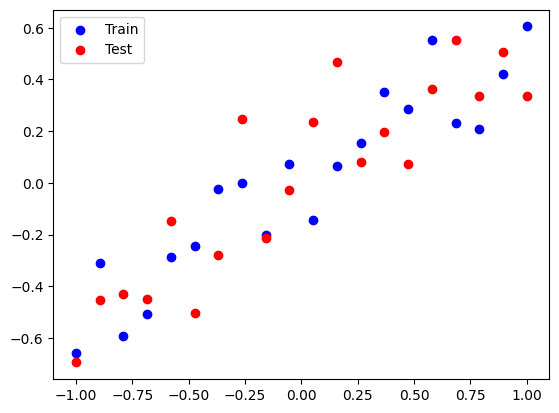

In [12]:
plt.scatter(x_train,y_train,c="b",label="Train")
plt.scatter(x_test,y_test,c="r",label="Test")
plt.legend()
plt.show()

In [16]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam


In [18]:
model = Sequential([
    Input(shape=(1,)),
    Dense(128,activation="relu"),
    Dense(128,activation="relu"),
    Dense(1,activation="linear")
])

In [19]:
adam = Adam(learning_rate=0.01)
model.compile(loss="mse",optimizer=adam,metrics=["mse"])

In [24]:
history=model.fit(x_train,y_train,epochs=500,validation_data=(x_test,y_test))

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - loss: 0.0049 - mse: 0.0049 - val_loss: 0.0453 - val_mse: 0.0453
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 763ms/step - loss: 0.0050 - mse: 0.0050 - val_loss: 0.0455 - val_mse: 0.0455
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - loss: 0.0053 - mse: 0.0053 - val_loss: 0.0464 - val_mse: 0.0464
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - loss: 0.0054 - mse: 0.0054 - val_loss: 0.0458 - val_mse: 0.0458
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - loss: 0.0051 - mse: 0.0051 - val_loss: 0.0454 - val_mse: 0.0454
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - loss: 0.0048 - mse: 0.0048 - val_loss: 0.0449 - val_mse: 0.0449
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - loss: 0.0048 - mse: 0.0048 - val_loss: 0.0447 - val_mse: 0.0447
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - loss: 0.0050 - mse: 0.0050 - val_loss: 0.0455 - val_mse: 0.0455
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - loss: 0.005

In [29]:
y_pred=model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


In [26]:
train_mse = model.evaluate(x_train,y_train,verbose=0)
test_mse = model.evaluate(x_test,y_test,verbose=0)

In [27]:
train_mse

[0.00020463830151129514, 0.00020463830151129514]

In [28]:
test_mse

[0.043992072343826294, 0.043992072343826294]

This causes overfitting. The loss while training is much lower than the loss while testing. To overcome this we use dropout methods so that my model can also understand the complexity of the data but not depend only on that itself. That's why we are going to use dropouts.


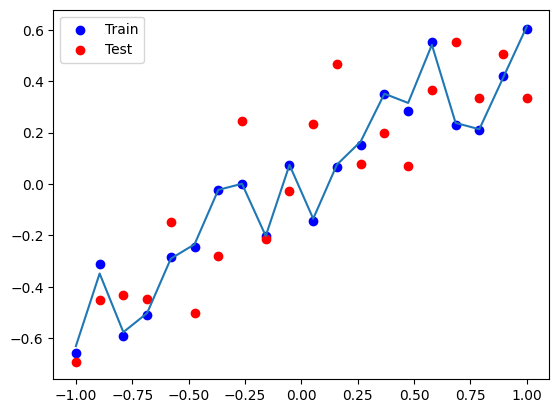

In [30]:
plt.scatter(x_train,y_train,c="b",label="Train")
plt.scatter(x_test,y_test,c="r",label="Test")
plt.plot(x_test,y_pred)
plt.legend()
plt.show()

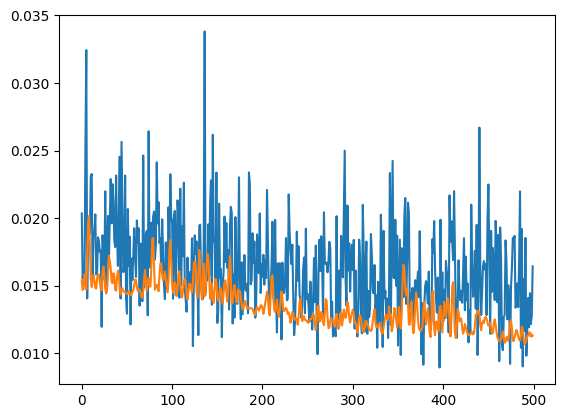

In [43]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

See when I predicted the x_test data for this model, I got an answer which is more towards the extreme, which is known as overfitting. That means my model is good for x_train but it is bad for x_test or unseen data. That's why we are going to use the dropout method here.

In [31]:
model = Sequential([
    Input(shape=(1,)),
    Dense(128,activation="relu"),
    Dropout(0.2),
    Dense(128,activation="relu"),
    Dropout(0.2),
    Dense(1,activation="linear")
])

In [32]:
adam = Adam(learning_rate=0.01)
model.compile(loss="mse",optimizer=adam,metrics=["mse"])

In [35]:
history=model.fit(x_train,y_train,epochs=500,validation_data=(x_train,y_train))

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - loss: 0.0204 - mse: 0.0204 - val_loss: 0.0154 - val_mse: 0.0154
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0155 - mse: 0.0155 - val_loss: 0.0147 - val_mse: 0.0147
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.0163 - mse: 0.0163 - val_loss: 0.0148 - val_mse: 0.0148
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.0154 - mse: 0.0154 - val_loss: 0.0159 - val_mse: 0.0159
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0248 - mse: 0.0248 - val_loss: 0.0156 - val_mse: 0.0156
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0324 - mse: 0.0324 - val_loss: 0.0147 - val_mse: 0.0147
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 0.0141 - mse: 0.0141 - val_loss: 0.0173 - val_mse: 0.0173
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.0194 - mse: 0.0194 - val_loss: 0.0196 - val_mse: 0.0196
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - loss: 0.0188 - m

In [36]:
y_pred=model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step


In [37]:
train_mse = model.evaluate(x_train,y_train)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - loss: 0.0113 - mse: 0.0113


In [38]:
train_mse

[0.011311104521155357, 0.011311104521155357]

In [39]:
test_mse = model.evaluate(x_test,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.0416 - mse: 0.0416


In [40]:
test_mse

[0.04155910760164261, 0.04155910760164261]

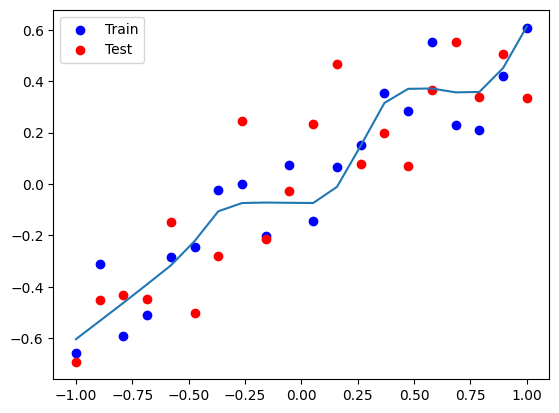

In [41]:
plt.scatter(x_train,y_train,c="b",label="Train")
plt.scatter(x_test,y_test,c="r",label="Test")
plt.plot(x_test,y_pred)
plt.legend()
plt.show()

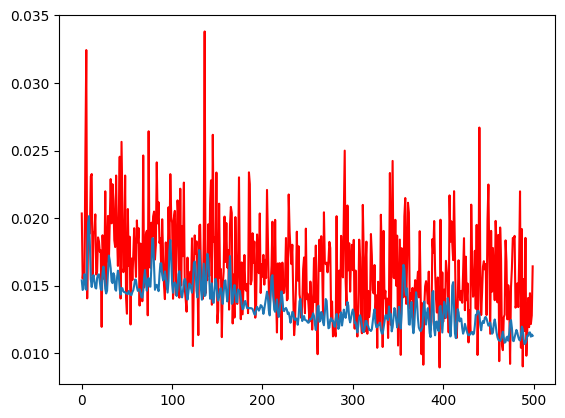

In [46]:
plt.plot(history.history['loss'],c="r")
plt.plot(history.history['val_loss'])

See after applying a dropout we are getting a much better line, or I can say a much, much better best-fit line. By applying a dropout this is one of the methods used to improve our neural networks.

In [48]:
model = Sequential([
    Input(shape=(1,)),
    Dense(128,activation="relu"),
    Dropout(0.5),
    Dense(128,activation="relu"),
    Dropout(0.5),
    Dense(1,activation="linear")
])

In [49]:
adam = Adam(learning_rate=0.01)
model.compile(loss="mse",optimizer=adam,metrics=["mse"])

In [50]:
history=model.fit(x_train,y_train,epochs=500,validation_data=(x_train,y_train))

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.1236 - mse: 0.1236 - val_loss: 0.0216 - val_mse: 0.0216
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.0426 - mse: 0.0426 - val_loss: 0.0217 - val_mse: 0.0217
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0264 - mse: 0.0264 - val_loss: 0.0192 - val_mse: 0.0192
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.0263 - mse: 0.0263 - val_loss: 0.0211 - val_mse: 0.0211
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.0461 - mse: 0.0461 - val_loss: 0.0182 - val_mse: 0.0182
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.0334 - mse: 0.0334 - val_loss: 0.0228 - val_mse: 0.0228
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0253 - mse: 0.0253 - val_loss: 0.0271 - val_mse: 0.0271
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.0173 - mse: 0.0173 - val_loss: 0.0260 - val_mse: 0.0260
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.0245 - 

In [51]:
y_pred=model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step


In [52]:
test_mse = model.evaluate(x_test,y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - loss: 0.0359 - mse: 0.0359


In [53]:
train_mse = model.evaluate(x_train,y_train)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0150 - mse: 0.0150


In [54]:
test_mse

[0.03585980087518692, 0.03585980087518692]

In [56]:
train_mse

[0.014989808201789856, 0.014989808201789856]

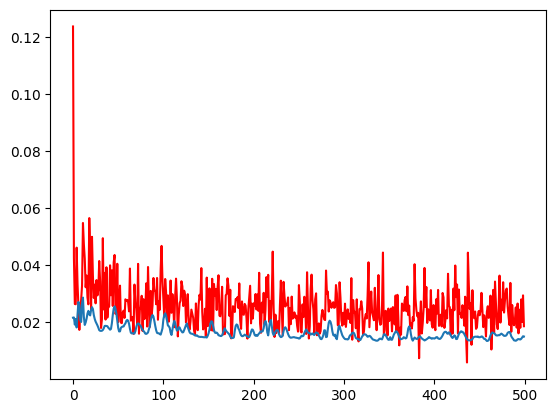

In [57]:
plt.plot(history.history['loss'],c="r")
plt.plot(history.history['val_loss'])

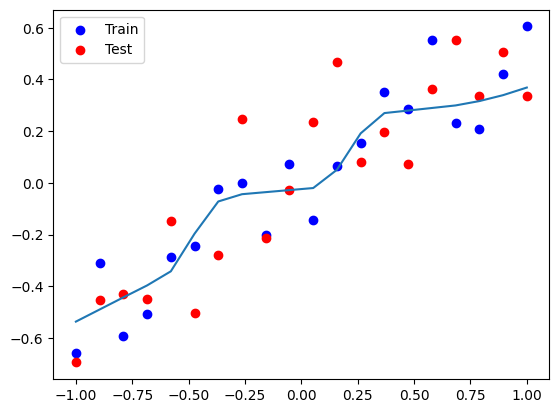

In [58]:
plt.scatter(x_train,y_train,c="b",label="Train")
plt.scatter(x_test,y_test,c="r",label="Test")
plt.plot(x_test,y_pred)
plt.legend()
plt.show()

See we have observed that if we increase dropout from 0.2 to 0.5. There is more enhancement or improvement in a neural network. That means the more the dropout, the more the enhancement in the neural network.